## Xenium data preprocessing
To be used as input by the scPortrait pipeline, the 10x Xenium dataset has to be converted to compatible file formats (preferably sdata format). This notebook contains code for processing the 10x Xenium bundle output from Xenium Onboard Analysis (XOA), cropping the dataset (for debugging and running on local machine), and saving the dataset for next steps (scPortrait pipeline).

The Xenium output bundle used in this notebook can be dowloaded at https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast

## Exploring SpatialData

In [1]:
# Import Xenium dataset

from spatialdata_io import xenium

input_path = "../data/raw/breast-cancer-10x-xenium-bundle"

sdata = xenium(input_path)

print(sdata)

SpatialData object
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
│     └── 'nucleus_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts 

In [2]:
# Inspect keys in the dataset
print(sdata.images.keys())
print(sdata.shapes.keys())
print(sdata.tables.keys())

dict_keys(['morphology_mip', 'morphology_focus'])
dict_keys(['nucleus_boundaries', 'cell_boundaries'])
dict_keys(['table'])


Xenium SpatialData object has 5 elements: (1) Images, (2) Labels, (3) Points, (4) Shapes, (5) Tables. 

`Images`: microscopy images in '.ome.tif' format (.tif images with additional metadata) --> Raster geometry (c - channel, y - height, x - width).    
`Labels`: cell and nucleus segmentation masks at pixel-level --> Raster geometry (c - channel, y - height, x - width).   
`Points`: transcript locations as coordinates (in micrometer) --> Vector geometry (3D coordinates and features).    
`Shapes`: ROI (2D shapes like polygons, circles, etc)  --> Vector geometry (Cell ID vs geometry).    
`Tables`: Single cell expression matrix (Anndata) --> Annotations for other elements (except images). 

In [3]:
sdata.points["transcripts"].head()

,x,y,z,feature_name,cell_id,qv,overlaps_nucleus,transcript_id
0,4.395842,328.666473,12.019493,SEC11C,565,18.662479,0,281474976710656
1,5.074415,236.964844,7.608510,NegControlCodeword_0502,540,18.634956,0,281474976710657
2,4.702023,322.797150,12.289083,SEC11C,562,18.662479,0,281474976710658
3,4.906601,581.428650,11.222615,DAPK3,271,20.821745,0,281474976710659
4,5.660699,720.851746,9.265523,TCIM,291,18.017488,0,281474976710660


In [4]:
sdata.shapes["cell_boundaries"].head()

,geometry
1,"POLYGON ((849.787 322.362, 844.263 323.212, 84..."
2,"POLYGON ((817.062 321.087, 816 329.375, 819.61..."
3,"POLYGON ((849.787 329.163, 847.875 330.438, 84..."
4,"POLYGON ((823.225 330.862, 821.525 331.5, 819...."
5,"POLYGON ((840.65 324.7, 835.763 326.612, 836.8..."


## Cropping 10x Xenium dataset

In [5]:
# Crop the dataset using a crop function (private repository function using spatialdata methods)
from data_processing.image_crop_function import image_crop

start = 8000
end = 4000

cropped_sdata, crop_xmin, crop_ymin = image_crop(
    sdata,
    start,
    start,
    start + end,
    start + end + 500,
    "global",
)

print(cropped_sdata)
print(crop_xmin, crop_ymin)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
│     └── 'morphology_mip': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
│     └── 'nucleus_labels': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (4202, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (4202, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (4202, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nu

After using the crop function, the cropped image contains 4202 cells (out of a total of 167780 cells). This corresponds to 2.5% of the total daatset.

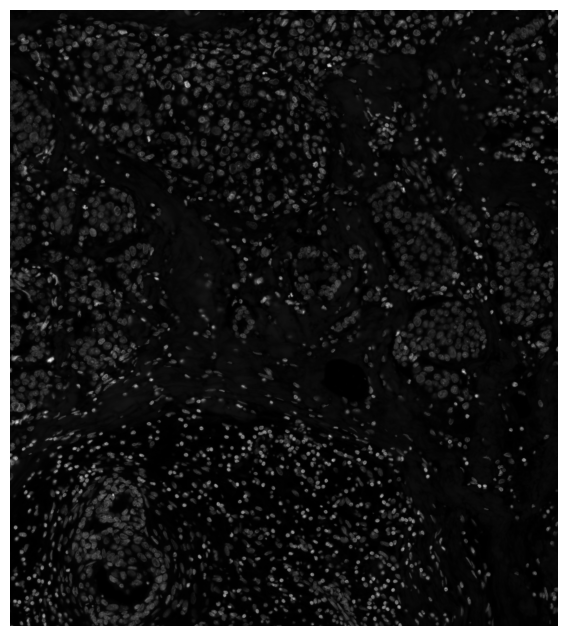

In [6]:
# Visualize the cropped image
import matplotlib.pyplot as plt

img_np = (
    cropped_sdata.images["morphology_focus"]["scale0"]["image"]
    .compute()
)

plt.figure(figsize=(8,8))
plt.imshow(img_np.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

In [7]:
# convert table index to str as this is what anndata prefers to work with
cropped_sdata["table"].obs.index = cropped_sdata["table"].obs.index.astype('str')

In [8]:
# Save the cropped dataset as .sdata.zarr)
output_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped.sdata.zarr"

cropped_sdata.write(output_path, overwrite = True)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/li

## Processing the cropped dataset (normalizing intensity)

In [9]:
# Import required libraries

import os
import matplotlib.pyplot as plt
import numpy as np
import scportrait


In [17]:
scportrait.tools.sdata.pp.percentile_normalize_image(cropped_sdata, 
                                                     image_name = "morphology_focus",
                                                     lower_percentile = 0.1, 
                                                     upper_percentile = 99.9, 
                                                     rescaled_image_name = "morphology_focus_rescaled")

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped.sdata.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
│     ├── 'morphology_focus_rescaled': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
│     └── 'morphology_mip': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
│     └── 'nucleus_labels': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (4202, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (4202, 1) (2D shapes)
└──

In [20]:
# Inspect the original and normalized images
orig = cropped_sdata.images["morphology_focus"]["scale0"]["image"].data.compute()
norm = cropped_sdata.images["morphology_focus_rescaled"]["scale0"]["image"].data.compute()

print(orig.min(), orig.max())
print(norm.min(), norm.max())

0 3844
0 65535


In [ ]:
# Inspect the percentiles of the original and normalized images
print(np.percentile(orig, [0, 0.1, 25, 50, 75, 90, 95, 99, 99.9, 100]))
print(np.percentile(norm, [0, 0.1, 25, 50, 75, 90, 95, 99, 99.9, 100]))

[   0.    8.   64.  123.  265.  627.  870. 1521. 2208. 3844.]
[    0.     0.  1668.  3425.  7655. 18439. 25677. 45070. 65535. 65535.]


Prior to segmentation, the morphology image is percentile normalized to improve contrast and standardize intensity values across the dataset. Note that after normalization, the intensities below 0.1 and above 99.9 percentiles are set as min (i.e. 0) and max (i.e. 65535) intensities respectively. The remaining intensity values are linearly rescaled to span the full 16-bit intensity range (0–65535). This normalization reduces the influence of extreme outlier pixels and improves the robustness of downstream segmentation algorithms without altering the underlying cellular morphology.

## Check Cell and Resource metrics (to configure parameters in the scPortrait config file)

In [23]:
# Check number of CPU cores available for processing
print(os.cpu_count())

192


In the scPortrait config file, you need to specify the number of threads (parallel worker processes) to be used during the single cell extraction step (`HDF5CellExtraction`) of scPortrait. For debugging using the cropped dataset, 8-16 threads is sufficient.

In [24]:
cropped_sdata["table"]


AnnData object with n_obs × n_vars = 4202 × 313
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
# Calculate cell boundary widths and heights to set the image_size in the scPortrait config.yml file
widths = []
heights = []

for geom in cropped_sdata["cell_boundaries"].geometry:
    minx, miny, maxx, maxy = geom.bounds
    widths.append(maxx - minx)
    heights.append(maxy - miny)

print("Median width:", np.median(widths))
print("Median height:", np.median(heights))
print("95th percentile width:", np.percentile(widths, 95))
print("95th percentile height:", np.percentile(heights, 95))

Median width: 15.9375
Median height: 15.9375
95th percentile width: 28.050048828125
95th percentile height: 28.049920654296876


In [26]:
areas = cropped_sdata["cell_boundaries"].area

print("Median area:", areas.median())
print("95th percentile area:", areas.quantile(0.95))

Median area: 150.4603020399809
95th percentile area: 445.65980044603344


`image_size` defines the width and height (in pixels) of the square image patch extracted around each segmented cell. This parameter is also required for the single cell extraction method `HDF5CellExtraction` and should be included in the config file. The value should be large enough to capture the entire cell along with a small amount of surrounding context, but not so large that it introduces excessive background or increases computational cost. Based on the observed cell size distribution (median width/height ≈ 16 pixels; 95th percentile ≈ 28 pixels), an image_size of 64 pixels provides sufficient context while maintaining computational efficiency.

With a 64 x 64 patch, the 95th percentile cell occupies ~44% of the patch width and there is ~18 pixels of context on each side ((64-28)/2).

In [27]:
# Check number of unique nucleus and cell labels in the cropped dataset (check if both match) 

import numpy as np

nuc = cropped_sdata.labels["nucleus_labels"]["scale0"]["image"].compute()
cell = cropped_sdata.labels["cell_labels"]["scale0"]["image"].compute()

print("nucleus labels:", len(np.unique(nuc)))
print("cell labels:", len(np.unique(cell)))
print("Missing nuclei labels:", len(np.unique(cell)) - len(np.unique(nuc)))

nucleus labels: 4115
cell labels: 4203
Missing nuclei labels: 88


This Xenium dataset contains DAPI as the segmentation stain and does not include a membrane (WGA) channel. Therefore among scPortrait's segmentation workflows, DAPISegmentation is the preferred choice for the initial scPortrait workflow instead of WGASegmentation, which requires both DAPI and WGA images. 

In the subsequent steps, after validating the scPortrait workflow using DAPISegmentation, the same pipeline will be executed using the Xenium onboard segmentation. This will enable a direct comparison of segmentation quality, single-cell extraction performance, and the resulting morphology features between the two segmentation approaches.